<a href="https://colab.research.google.com/github/apcyssr/2026_Spring_KBU/blob/main/20260313_%EA%B3%BC%EC%A0%9C_(ETL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **20260313 과제 (ETL)**

In [ ]:
import requests
import json
import pandas as pd
import os

# --- Step 1: Fetch data and save to JSON ---
def load_data_from_api():
    url = 'https://ll.thespacedevs.com/2.0.0/launch/upcoming'

    try:
        print("Fetching data from API...")
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()

        # Create a folder for storing data (if it doesn't exist)
        os.makedirs('data', exist_ok=True)

        # Save as launches.json file
        with open('data/launches.json', 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=4)

        # Convert to DataFrame to check structure (extract only 'results' part)
        df = pd.DataFrame(data['results'])
        print("\n--- Data Structure (First 5 rows) ---")
        print(df[['name', 'net', 'image']].head())

        return data['results']

    except Exception as e:
        print(f"An error occurred in Step 1: {e}")
        return None

# --- Step 2: Extract image URLs and download ---
def get_pictures(launch_data):
    if not launch_data:
        return

    # Create a folder for storing images
    os.makedirs('images', exist_ok=True)

    print("\nStarting image downloads...")

    for item in launch_data:
        image_url = item.get('image')
        # Sanitize the filename by replacing spaces and slashes
        launch_name = item.get('name').replace(" ", "_").replace("/", "-")

        if not image_url:
            print(f"Skipped: {launch_name} (No image URL)")
            continue

        try:
            # Download image data
            img_response = requests.get(image_url, timeout=10)
            img_response.raise_for_status()

            # Save image file (named after the rocket)
            file_path = f"images/{launch_name}.jpg"
            with open(file_path, 'wb') as f:
                f.write(img_response.content)
            print(f"Success: {launch_name}")

        except requests.exceptions.RequestException as e:
            print(f"Failed: {launch_name} due to {e}")

# --- Execute Program ---
if __name__ == "__main__":
    # Step 1
    results = load_data_from_api()

    # Step 2
    if results:
        get_pictures(results)

Fetching data from API...

--- Data Structure (First 5 rows) ---
                                      name                   net  \
0      Long March 8A | SatNet LEO Group 20  2026-03-12T19:48:00Z   
1          Long March 2D | Shiyan 30 03-04  2026-03-12T22:33:00Z   
2  Falcon 9 Block 5 | Starlink Group 10-48  2026-03-13T12:10:40Z   
3  Falcon 9 Block 5 | Starlink Group 17-31  2026-03-13T14:33:50Z   
4          Long March 6A | Unknown Payload  2026-03-15T13:20:00Z   

                                               image  
0  https://thespacedevs-prod.nyc3.digitaloceanspa...  
1  https://thespacedevs-prod.nyc3.digitaloceanspa...  
2  https://thespacedevs-prod.nyc3.digitaloceanspa...  
3  https://thespacedevs-prod.nyc3.digitaloceanspa...  
4  https://thespacedevs-prod.nyc3.digitaloceanspa...  

Starting image downloads...
Success: Long_March_8A_|_SatNet_LEO_Group_20
Success: Long_March_2D_|_Shiyan_30_03-04
Success: Falcon_9_Block_5_|_Starlink_Group_10-48
Success: Falcon_9_Block_5_|_Star

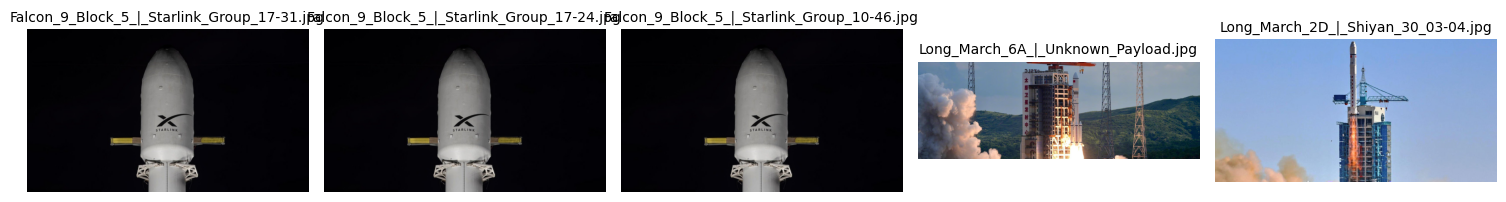

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import math

# Define the folder path
folder_path = 'images'

# Get a list of all files in the folder
image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Limit to the first 5 images (or remove the [:5] to show all)
images_to_show = image_files[:5]

if images_to_show:
    # Set the number of columns for the grid
    cols = 5
    rows = math.ceil(len(images_to_show) / cols)

    # Create a figure with a specific size
    plt.figure(figsize=(15, 5 * rows))

    for i, file_name in enumerate(images_to_show):
        # Create a subplot for each image
        plt.subplot(rows, cols, i + 1)

        # Load and display the image
        img_path = os.path.join(folder_path, file_name)
        img = Image.open(img_path)
        plt.imshow(img)

        # Set the title and turn off the axis for a cleaner look
        plt.title(file_name, fontsize=10)
        plt.axis('off')

    # Adjust layout to prevent overlapping
    plt.tight_layout()
    plt.show()
else:
    print("No images found in the folder.")

--- Iris Dataset Overview ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

--- Statistical Summary ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000        

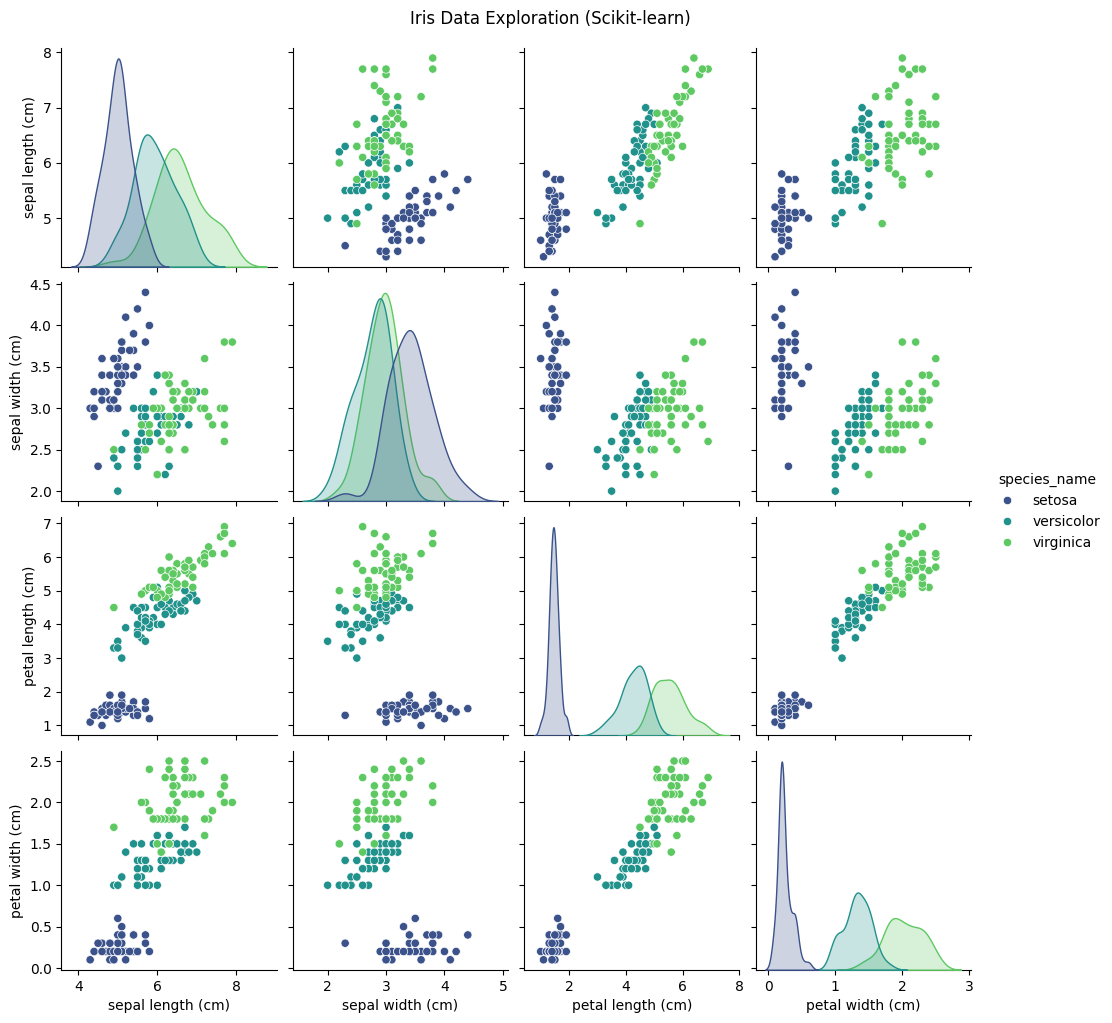

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def explore_scikit_learn_data():
    # Load the Iris dataset from scikit-learn
    iris = load_iris()

    # Create a DataFrame using the data and feature names
    df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

    # Add the target (species) column to the DataFrame
    df['species'] = iris.target

    # Map numerical target values to actual species names
    df['species_name'] = df['species'].map({
        i: name for i, name in enumerate(iris.target_names)
    })

    print("--- Iris Dataset Overview ---")
    # Display the first 5 rows of the processed data
    print(df.head())

    # Display statistical summary of the dataset
    print("\n--- Statistical Summary ---")
    print(df.describe())

    # Visualization: Plotting the relationship between features
    print("\nGenerating pairplot...")
    sns.pairplot(df.drop('species', axis=1), hue='species_name', palette='viridis')
    plt.suptitle("Iris Data Exploration (Scikit-learn)", y=1.02)
    plt.show()

# Run the exploration
explore_scikit_learn_data()